In [4]:
# load in packages
library(sf)
library(terra)
library(tidyterra)
library(ggnewscale)   
library(dplyr)
library(ggplot2)
# Load library to calculate acres
library(units)

# set max memory usage limit
terraOptions(memmax = 3.5)

Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE



terra 1.8.60




Attaching package: ‘tidyterra’




The following object is masked from ‘package:stats’:

    filter





Attaching package: ‘dplyr’




The following objects are masked from ‘package:terra’:

    intersect, union




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




udunits database from /usr/share/xml/udunits/udunits2.xml



In [5]:
getwd()
municipalities <- st_read("/home/user/eds_certificate_capstone/agrivoltaics_in_ri/data/raw_data/BND_Municipalities_1997_spf/ri_municipalities_1997.shp")

land_use <- st_read("/home/user/eds_certificate_capstone/agrivoltaics_in_ri/data/raw_data/land_cover_use_2020/land_cover_use_2020.shp")%>% 
  filter(Descr_2020 %in% c("Idle Agriculture (abandoned fields and orchards)", "Cropland (tillable)", "Pasture (agricultural not suitable for tillage)", "Orchards, Groves, Nurseries"))


[1] "/home/user/eds_certificate_capstone/agrivoltaics_in_ri/scripts"

Reading layer `ri_municipalities_1997' from data source 
  `/home/user/eds_certificate_capstone/agrivoltaics_in_ri/data/raw_data/BND_Municipalities_1997_spf/ri_municipalities_1997.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 396 features and 10 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 220310.4 ymin: 23048.49 xmax: 432040.9 ymax: 340916.6
Projected CRS: NAD83 / Rhode Island (ftUS)


Reading layer `land_cover_use_2020' from data source 
  `/home/user/eds_certificate_capstone/agrivoltaics_in_ri/data/raw_data/land_cover_use_2020/land_cover_use_2020.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 68618 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 220000 ymin: 23051.56 xmax: 434591.9 ymax: 343511.1
Projected CRS: NAD83 / Rhode Island (ftUS)


In [6]:
print(land_use)

Simple feature collection with 5431 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 230746.8 ymin: 23194.6 xmax: 434465.9 ymax: 343511.1
Projected CRS: NAD83 / Rhode Island (ftUS)
First 10 features:
   State LULC_2020                                      Descr_2020 Acres_2020
1     CT       210 Pasture (agricultural not suitable for tillage)   15.90290
2     CT       210 Pasture (agricultural not suitable for tillage)    0.93909
3     CT       210 Pasture (agricultural not suitable for tillage)    2.10937
4     CT       210 Pasture (agricultural not suitable for tillage)    1.26342
5     CT       210 Pasture (agricultural not suitable for tillage)    8.53504
6     CT       210 Pasture (agricultural not suitable for tillage)    1.75153
7     CT       210 Pasture (agricultural not suitable for tillage)   14.32640
8     CT       210 Pasture (agricultural not suitable for tillage)   11.22200
9     CT       210 Pasture (agricultural not suitable for tilla

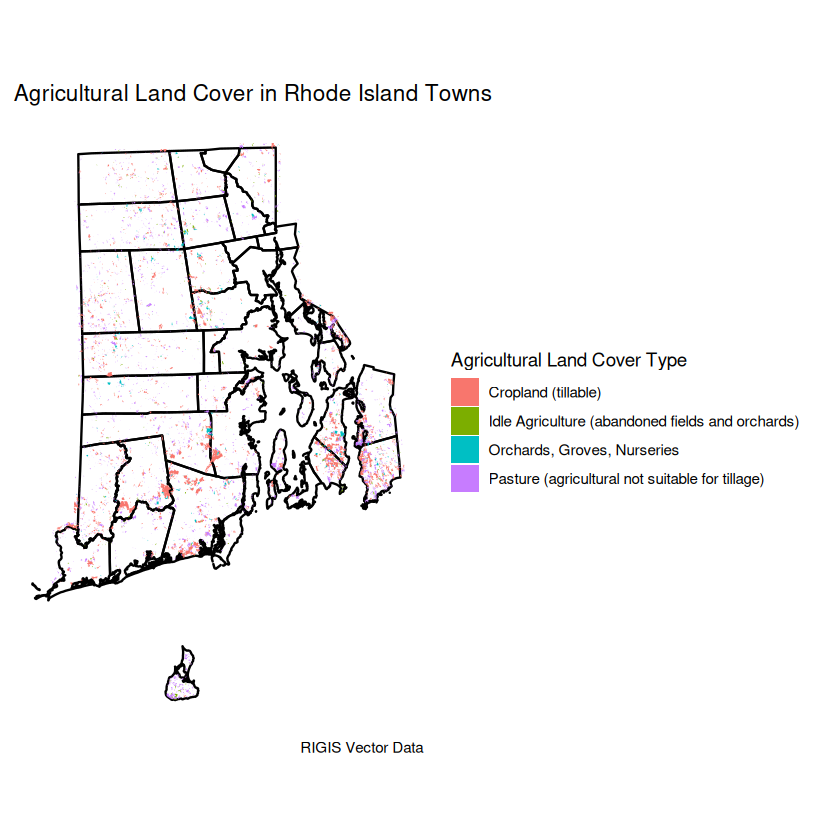

In [7]:
(ri_land_use_munic_map <- ggplot() +
  # Add municipality boundaries with black outlines
  geom_sf(data = municipalities, fill = NA, color = "black", linewidth = 0.5) +
  geom_sf(data = land_use, aes(fill = Descr_2020), color = NA) +
  theme_minimal() +
  labs(
    title = "Agricultural Land Cover in Rhode Island Towns",
    fill = "Agricultural Land Cover Type",
    caption = "RIGIS Vector Data"
  ) +
  theme(
    axis.text = element_blank(), 
    axis.title = element_blank(),  
    panel.grid = element_blank()))

In [8]:
print(municipalities)

Simple feature collection with 396 features and 10 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 220310.4 ymin: 23048.49 xmax: 432040.9 ymax: 340916.6
Projected CRS: NAD83 / Rhode Island (ftUS)
First 10 features:
   RITOWN5K_ RITOWN5K_I             NAME MCD CFIPS     COUNTY OSP CFIPS_MCD
1          2        380       CUMBERLAND  20     7 PROVIDENCE   8      7020
2          3          1       WOONSOCKET  80     7 PROVIDENCE  39      7080
3          4          2 NORTH SMITHFIELD  55     7 PROVIDENCE  25      7055
4          5          3     BURRILLVILLE   5     7 PROVIDENCE   3      7005
5          6        381          LINCOLN  45     7 PROVIDENCE  17      7045
6          7          4       SMITHFIELD  75     7 PROVIDENCE  31      7075
7          8          5        GLOCESTER  35     7 PROVIDENCE  13      7035
8          9          6    CENTRAL FALLS  10     7 PROVIDENCE   4      7010
9         10          7        PAWTUCKET  60     7 PROVIDENCE  26      7060
10  

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


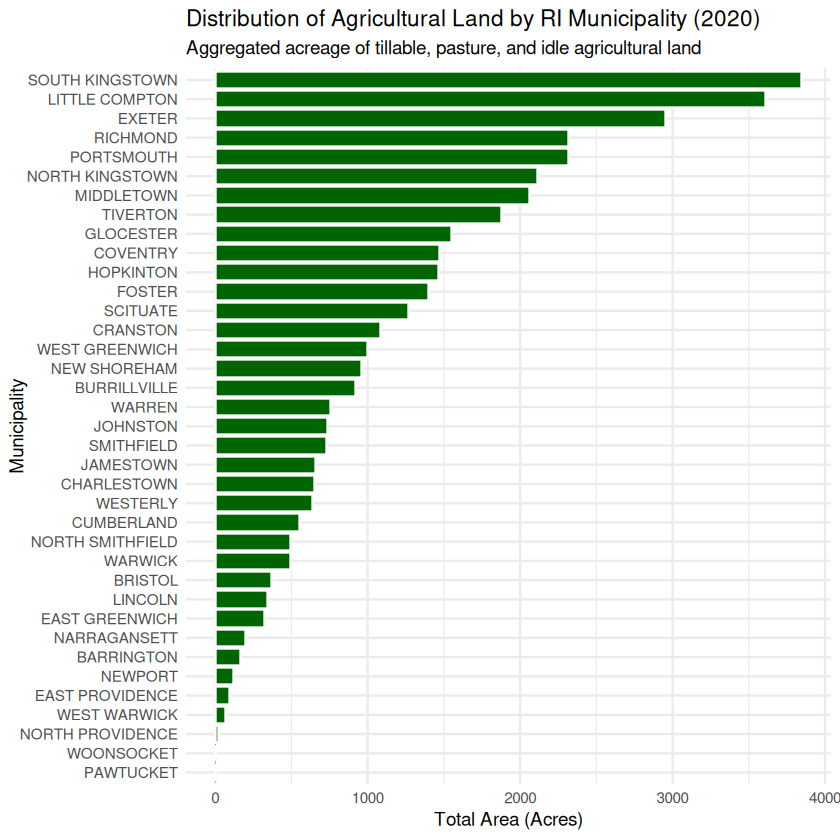

In [9]:
# cut the land_use polygons by the municipality boundaries
intersections <- st_intersection(land_use, municipalities)

# calculate the area of the new intersected pieces - farmland between town lines
intersections$area_sqm <- st_area(intersections)

# Create a summary plot
muni_farm_land_use <- intersections %>%
  st_drop_geometry() %>% # Convert to a standard table for faster math
  group_by(NAME) %>%
  summarize(Total_Acres = sum(Acres_2020, na.rm = TRUE)) %>%
  arrange(desc(Total_Acres))

# create a bar chart of total farmland acreage by municipality
ggplot(muni_farm_land_use, aes(x = reorder(NAME, Total_Acres), y = Total_Acres)) +
  geom_col(fill = "darkgreen", color = "white") +
     coord_flip() +  # Flip the chart to make municipality names readable
  labs(
    title = "Distribution of Agricultural Land by RI Municipality (2020)",
    subtitle = "Aggregated acreage of tillable, pasture, and idle agricultural land",
    x = "Municipality",
    y = "Total Area (Acres)"
  ) +
  theme_minimal()

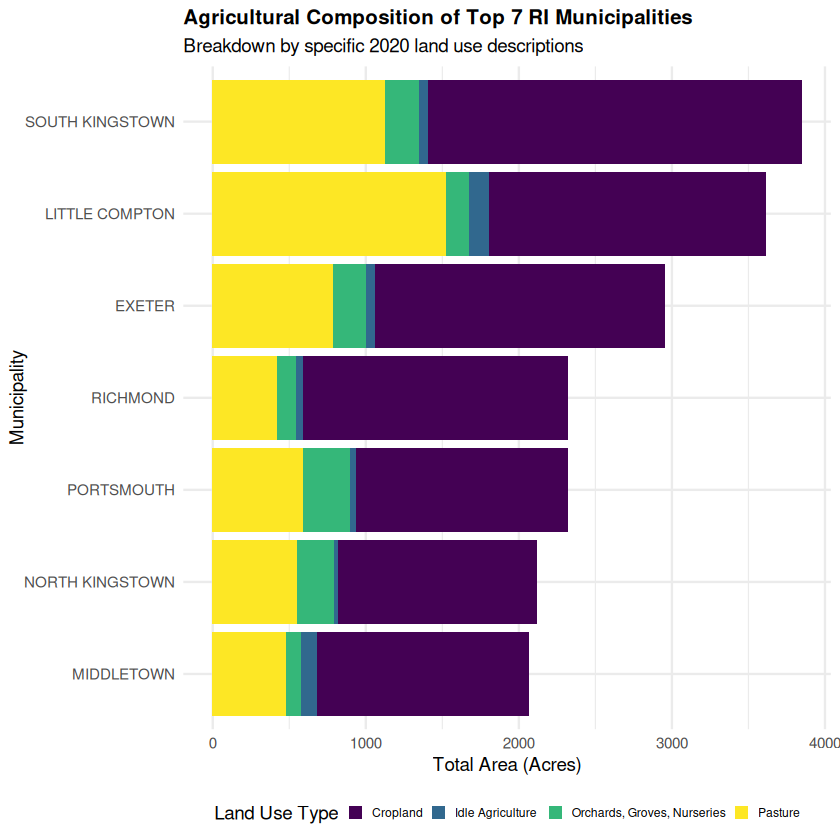

In [24]:
# 1. First, identify the names of the Top 7 municipalities to use as a filter
top_7_muni_farm <- intersections %>%
  st_drop_geometry() %>%
  group_by(NAME) %>%
  summarize(Total = sum(Acres_2020, na.rm = TRUE)) %>%
  slice_max(Total, n = 7) %>%
  pull(NAME)

# 2. Filter the main data for these 7 towns and group by both Name and Type
muni_type_breakdown <- intersections %>%
  st_drop_geometry() %>%
  filter(NAME %in% top_7_muni_farm) %>%
  group_by(NAME, Descr_2020) %>%
  summarize(Type_Acres = sum(Acres_2020, na.rm = TRUE), .groups = "drop")

# Change labels
my_labels <- c("Cropland (tillable)" = "Cropland", 
               "Idle Agriculture (abandoned fields and orchards)" = "Idle Agriculture", 
               "Orchards, Groves, Nurseries" = "Orchards, Groves, Nurseries",
               "Pasture (agricultural not suitable for tillage)" = "Pasture"
              )

# 3. Create a stacked bar chart
breakdown_bar_chart <- ggplot(muni_type_breakdown, 
                        aes(x = reorder(NAME, Type_Acres, sum), 
                            y = Type_Acres, 
                            fill = Descr_2020)) +
  geom_col() +
  coord_flip() +
  scale_fill_viridis_d(option = "viridis", name = "Land Use Type", labels = my_labels) + # Clean color palette
  labs(
    title = "Agricultural Composition of Top 7 RI Municipalities",
    subtitle = "Breakdown by specific 2020 land use descriptions",
    x = "Municipality",
    y = "Total Area (Acres)"
  ) +
  theme_minimal() +
  theme(
    legend.text = element_text(size = 7),       
    legend.key.size = unit(0.3, "cm"),          
    legend.position = "bottom",
    plot.title = element_text(size = 12, face = "bold"))

breakdown_bar_chart

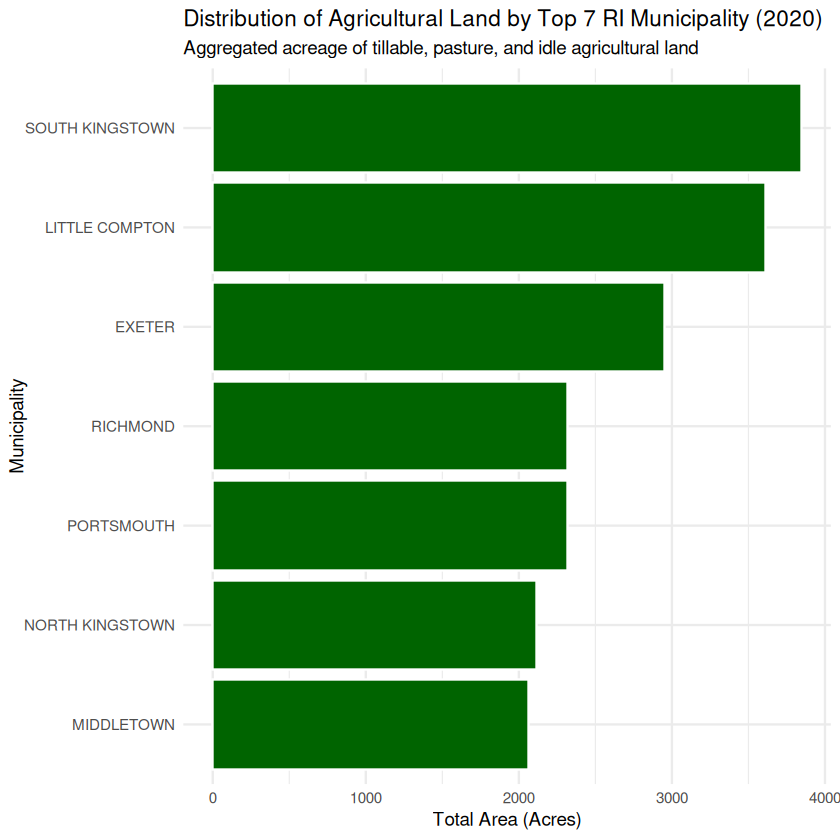

In [9]:
top_7_muni_farm <- muni_farm_land_use %>%
slice_max(order_by = Total_Acres, n = 7) %>% 
  arrange(desc(Total_Acres))

# create a bar chart of total farmland acreage by municipality
ggplot(top_7_muni_farm, aes(x = reorder(NAME, Total_Acres), y = Total_Acres)) +
  geom_col(fill = "darkgreen", color = "white") +
     coord_flip() +  # Flip the chart to make municipality names readable
  labs(
    title = "Distribution of Agricultural Land by Top 7 RI Municipality (2020)",
    subtitle = "Aggregated acreage of tillable, pasture, and idle agricultural land",
    x = "Municipality",
    y = "Total Area (Acres)"
  ) +
  theme_minimal()

## Analyze Existing Solar Farms in Rhode Island



Clean Data on Existing Solar Farms in Rhode Island


In [31]:
ri_existing_solar_farms <- st_read("/home/user/eds_certificate_capstone/agrivoltaics_in_ri/data/raw_data/solar_farms_ri/solar_farms_ri.shp")
    

print(ri_existing_solar_farms)

Reading layer `solar_farms_ri' from data source 
  `/home/user/eds_certificate_capstone/agrivoltaics_in_ri/data/raw_data/solar_farms_ri/solar_farms_ri.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1417 features and 3 fields
Geometry type: MULTIPOLYGON
Dimension:     XY, XYZ
Bounding box:  xmin: -189389.9 ymin: 95886.7 xmax: 742273.5 ymax: 649793.5
z_range:       zmin: 0 zmax: 0
Projected CRS: NAD83 / Rhode Island (ftUS)


Simple feature collection with 1417 features and 3 fields
Geometry type: MULTIPOLYGON
Dimension:     XY, XYZ
Bounding box:  xmin: -189389.9 ymin: 95886.7 xmax: 742273.5 ymax: 649793.5
z_range:       zmin: 0 zmax: 0
Projected CRS: NAD83 / Rhode Island (ftUS)
First 10 features:
   NameplateC OperatingM OperatingY                       geometry
1         3.3         10       2020 MULTIPOLYGON Z (((283546.9 ...
2         3.3         10       2020 MULTIPOLYGON Z (((283842.3 ...
3         0.0          6       2022 MULTIPOLYGON Z (((300829.1 ...
4         1.8         12       2020 MULTIPOLYGON Z (((301890 28...
5         0.0         10       2021 MULTIPOLYGON Z (((275528.8 ...
6         2.0         12       2017 MULTIPOLYGON Z (((250011.9 ...
7         4.8         11       2020 MULTIPOLYGON Z (((310049 19...
8         4.8         11       2020 MULTIPOLYGON Z (((310011.8 ...
9         0.0          3       2020 MULTIPOLYGON Z (((308499.2 ...
10        0.0          9       2019 MULTIPOLYGON Z ((

Split solar farms by municipality and identify total electrical capacity in MW by municipality and total solar land use in acres by municipality. Compare them using faceted bar charts. 



Simple feature collection with 173 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 234405.2 ymin: 95886.7 xmax: 426400.6 ymax: 338695.9
Projected CRS: NAD83 / Rhode Island (ftUS)
First 10 features:
   NameplateC OperatingM OperatingY                       geometry
1         3.3         10       2020 MULTIPOLYGON (((283546.9 31...
2         3.3         10       2020 MULTIPOLYGON (((283842.3 31...
3         0.0          6       2022 MULTIPOLYGON (((300829.1 31...
4         1.8         12       2020 MULTIPOLYGON (((301890 2837...
5         0.0         10       2021 MULTIPOLYGON (((275528.8 27...
6         2.0         12       2017 MULTIPOLYGON (((250011.9 25...
7         4.8         11       2020 MULTIPOLYGON (((310049 1948...
8         4.8         11       2020 MULTIPOLYGON (((310011.8 19...
9         0.0          3       2020 MULTIPOLYGON (((308499.2 19...
10        0.0          9       2019 MULTIPOLYGON (((269493.4 27...
   total_farm_area_acres

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


# A tibble: 27 × 4
   NAME             total_acres total_mw avg_mw_by_acre
   <chr>                  <dbl>    <dbl>          <dbl>
 1 WEST GREENWICH         317.     88.0            0.28
 2 NORTH SMITHFIELD       198.     31.8            0.16
 3 NORTH KINGSTOWN        139.     11.9            0.09
 4 CRANSTON               118.     26.2            0.22
 5 HOPKINTON              118.      5.10           0.04
 6 PORTSMOUTH              96.1    25.5            0.27
 7 JOHNSTON                78.4    14.4            0.18
 8 RICHMOND                72.7    13.8            0.19
 9 TIVERTON                63.9    10.8            0.17
10 SMITHFIELD              50.0     2.40           0.05
# ℹ 17 more rows


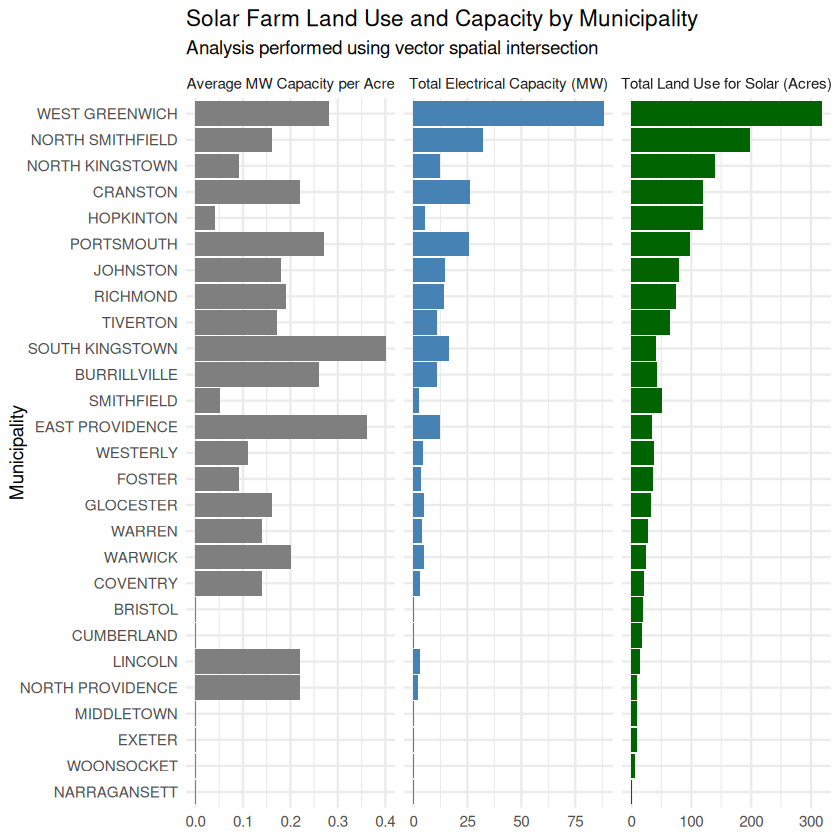

In [32]:
# The Solar Farm dataset is in 3D (xyz) and needs to be 2D (xy) to match the municipalities dataset.
# Clean the solar farms data by dropping the Z dimension
ri_existing_solar_farms <- ri_existing_solar_farms %>%
    st_zm() %>%
    st_filter(municipalities) %>%
    mutate(total_farm_area_acres = as.numeric(set_units(st_area(.), acre)))

print(ri_existing_solar_farms)

# Spatial Intersection: Calculate the area of fragments that fall within municipality boundaries
intersections <- st_intersection(ri_existing_solar_farms, municipalities) %>%
    mutate(
        fragment_area_acres = as.numeric(set_units(st_area(.), acre)),
        adjusted_mw = (fragment_area_acres / total_farm_area_acres) * NameplateC)

# Create a summary plot
muni_solar <- intersections %>%
    st_drop_geometry() %>%
    group_by(NAME) %>%
    summarize(
        total_acres = sum(fragment_area_acres, na.rm = TRUE),
        total_mw = sum(adjusted_mw, na.rm = TRUE),
        avg_mw_by_acre = round(mean(total_mw / total_acres, na.rm = TRUE), digits = 2)) %>%
    arrange(desc(total_acres))

print(muni_solar)

# reshapng the data from "wide" to "long" format for ggplot
# Puts metrics in one column and values in another
muni_solar_long <- muni_solar %>%
    pivot_longer(
        cols = c(total_acres, total_mw, avg_mw_by_acre),
        names_to = "metric",
        values_to = "value") %>%
    mutate(metric = recode(metric,
        total_acres = "Total Land Use for Solar (Acres)",
        total_mw = "Total Electrical Capacity (MW)",
        avg_mw_by_acre = 'Average MW Capacity per Acre')
)

# create a bar chart of total farmland acreage by municipality
ggplot(muni_solar_long, aes(x = reorder(NAME, value), y = value, fill = metric)) +
    geom_col(show.legend = FALSE) +
    coord_flip() + # Flip the chart to make municipality names readable
    facet_wrap(~ metric, scales = "free_x") +
    labs(
        title = "Solar Farm Land Use and Capacity by Municipality",
        subtitle = "Analysis performed using vector spatial intersection",
        x = "Municipality",
        y = NULL) +
    scale_fill_manual(values = c("Total Land Use for Solar (Acres)" = "darkgreen",
"Total Electrical Capacity (MW)" = "steelblue")) +
theme_minimal()

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


NAME,total_acres,total_mw
<chr>,<dbl>,<dbl>
BRISTOL,19.10341,0.0
BURRILLVILLE,42.15200,10.9
COVENTRY,20.71671,3.0
CRANSTON,118.22329,26.2
CUMBERLAND,16.93835,0.0
EAST PROVIDENCE,33.54796,12.0


,NAME,total_acres,total_mw
,<chr>,<dbl>,<dbl>
1,WEST GREENWICH,317.2228,88.0
2,NORTH SMITHFIELD,197.5738,31.8
3,NORTH KINGSTOWN,138.6796,11.9
4,NORTH KINGSTOWN,138.6796,11.9
5,NORTH KINGSTOWN,138.6796,11.9
6,NORTH KINGSTOWN,138.6796,11.9


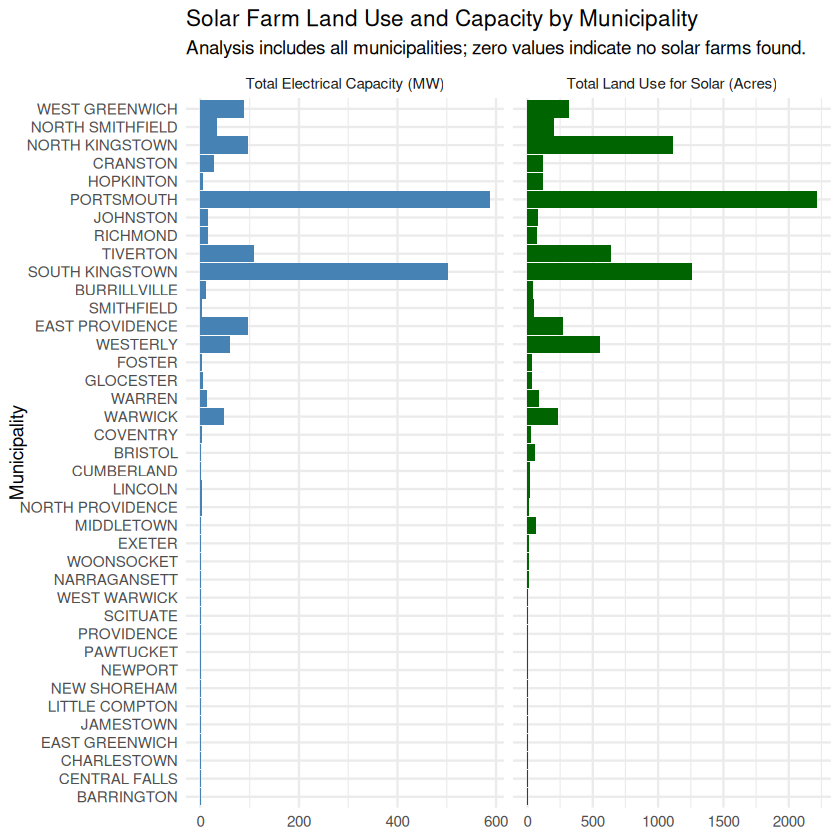

In [19]:
# cut the ri_existing_solar_farms polygons by the municipality boundaries
intersections <- st_intersection(ri_existing_solar_farms, municipalities)

# Calculate the area and adjusted MW for the intersected pieces
intersections <- intersections %>%
  mutate(
    fragment_area_acres = as.numeric(units::set_units(st_area(.), acre)),
    adjusted_mw = (fragment_area_acres / area_acres) * NameplateC
  )

# Create a summary of solar data by municipality
muni_solar_summary <- intersections %>%
  st_drop_geometry() %>%
  group_by(NAME) %>%
  summarize(
    total_acres = sum(fragment_area_acres, na.rm = TRUE), 
    total_mw = sum(adjusted_mw, na.rm = TRUE))

head(muni_solar_summary)

# Join with the full list of municipalities to keep those with 0 solar data
# Replace_na to turn missing values into 0 for the plot
muni_solar <- municipalities %>%
  st_drop_geometry() %>%
  select(NAME) %>%
  left_join(muni_solar_summary, by = "NAME") %>%
  mutate(
    total_acres = replace_na(total_acres, 0),
    total_mw = replace_na(total_mw, 0)
  ) %>%
  arrange(desc(total_acres))

head(muni_solar)

# Reshape the data to "long" format for ggplot
muni_solar_long <- muni_solar %>%
  pivot_longer(cols = c(total_acres, total_mw), 
               names_to = "metric", 
               values_to = "value") %>%
  mutate(metric = recode(metric, 
                         total_acres = "Total Land Use for Solar (Acres)", 
                         total_mw = "Total Electrical Capacity (MW)"))
         
# Create the bar chart
viz1 <- ggplot(muni_solar_long, aes(x = reorder(NAME, value), y = value, fill = metric)) +
  geom_col(show.legend = FALSE) +
  coord_flip() + 
  facet_wrap(~ metric, scales = "free_x") +
  labs(
    title = "Solar Farm Land Use and Capacity by Municipality",
    subtitle = "Analysis includes all municipalities; zero values indicate no solar farms found.",
    x = "Municipality",
    y = NULL
  ) +
  scale_fill_manual(values = c("Total Land Use for Solar (Acres)" = "darkgreen", 
                               "Total Electrical Capacity (MW)" = "steelblue")) +
  theme_minimal()
         
 viz1        

In [13]:
ttl_avg_mw_by_acre <- round(mean(muni_solar$total_mw / muni_solar$total_acres, na.rm = TRUE), digits = 2)
ttl_avg_mw_by_acre

[1] 0.15

## Farmland Classifications

Prime and Important Farmland 


In [29]:
ri_farmland <- st_read("/home/user/eds_certificate_capstone/agrivoltaics_in_ri/data/raw_data/prime_and_important_farmland/farmland_classification.shp")

print(ri_farmland)

Reading layer `farmland_classification' from data source 
  `/home/user/eds_certificate_capstone/agrivoltaics_in_ri/data/raw_data/prime_and_important_farmland/farmland_classification.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 13662 features and 0 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 229670.9 ymin: 23276.88 xmax: 431952.2 ymax: 340884.9
Projected CRS: NAD83 / Rhode Island (ftUS)


Simple feature collection with 13662 features and 0 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 229670.9 ymin: 23276.88 xmax: 431952.2 ymax: 340884.9
Projected CRS: NAD83 / Rhode Island (ftUS)
First 10 features:
                         geometry
1  POLYGON ((395116.9 177266, ...
2  POLYGON ((331077.1 151885.7...
3  POLYGON ((280930.9 291695.3...
4  POLYGON ((268628.2 180471.3...
5  POLYGON ((266168.9 175731.3...
6  POLYGON ((250190.9 179431.4...
7  POLYGON ((424770.7 180678.7...
8  POLYGON ((419871.4 185174.4...
9  POLYGON ((358092.4 139053.7...
10 POLYGON ((342201.3 187418.7...


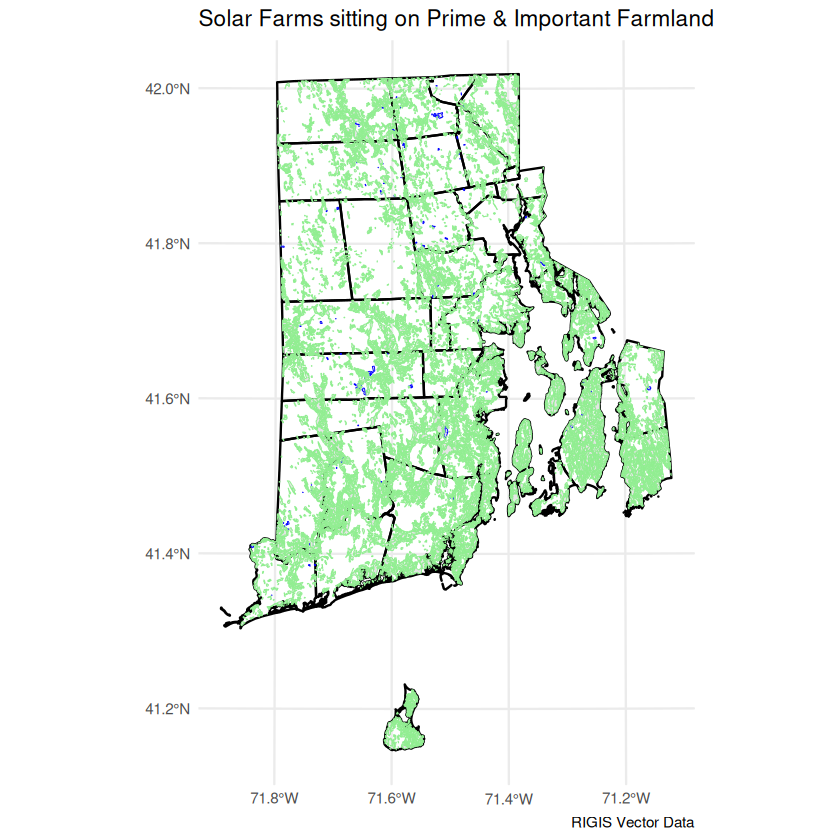

In [30]:
(ri_solar_on_farmland_soil <- ggplot() +
  # Add municipality boundaries with black outlines
  geom_sf(data = municipalities, fill = NA, color = "black", linewidth = 0.5) +
  geom_sf(data = ri_existing_solar_farms, color = "blue") +
  geom_sf(data = ri_farmland, color = "lightgreen") +
  theme_minimal() +
  labs(
    title = "Solar Farms sitting on Prime & Important Farmland", 
    caption = "RIGIS Vector Data"))

In [31]:
# Identify which solar farms intersect with classified farmland. Using st_filter to keep the original solar farm polygons that touch farmland
solar_farmland_overlap <- st_intersection(ri_existing_solar_farms, ri_farmland)

# Calculate the area of overlap in Acres - divide by 43560 because the CRS units are in feet (ftUS)
solar_farmland_overlap <- solar_farmland_overlap %>%
  mutate(overlap_sqft = as.numeric(st_area(.)),
         overlap_acres = overlap_sqft / 43560)

head(solar_farmland_overlap)

# Total acres of farmland occupied by solar
total_impacted_acres <- sum(solar_farmland_overlap$overlap_acres)

cat("Total overlap area (Acres):", round(total_impacted_acres, 2), "\n")

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


,NameplateC,OperatingM,OperatingY,area_acres,geometry,overlap_sqft,overlap_acres
,<dbl>,<dbl>,<dbl>,<dbl>,<GEOMETRY [US_survey_foot]>,<dbl>,<dbl>
129,0,10,2021,12.4818500,MULTIPOLYGON (((425745.8 18...,439588.67905,10.091567471
57,2,6,2019,9.9661819,POLYGON ((313610.3 258221.6...,56491.85113,1.296874452
57.1,2,6,2019,9.9661819,POLYGON ((313315.4 258928.2...,237298.93629,5.447633983
98,0,11,2022,0.2994768,POLYGON ((337382.7 116617.1...,8444.93568,0.193869047
75,0,12,2019,3.5586199,POLYGON ((285219.7 195075.4...,49.89108,0.001145342
78,24,12,2019,43.9155208,MULTIPOLYGON (((285095.7 19...,180663.75445,4.147469110


Total overlap area (Acres): 482.62 


Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


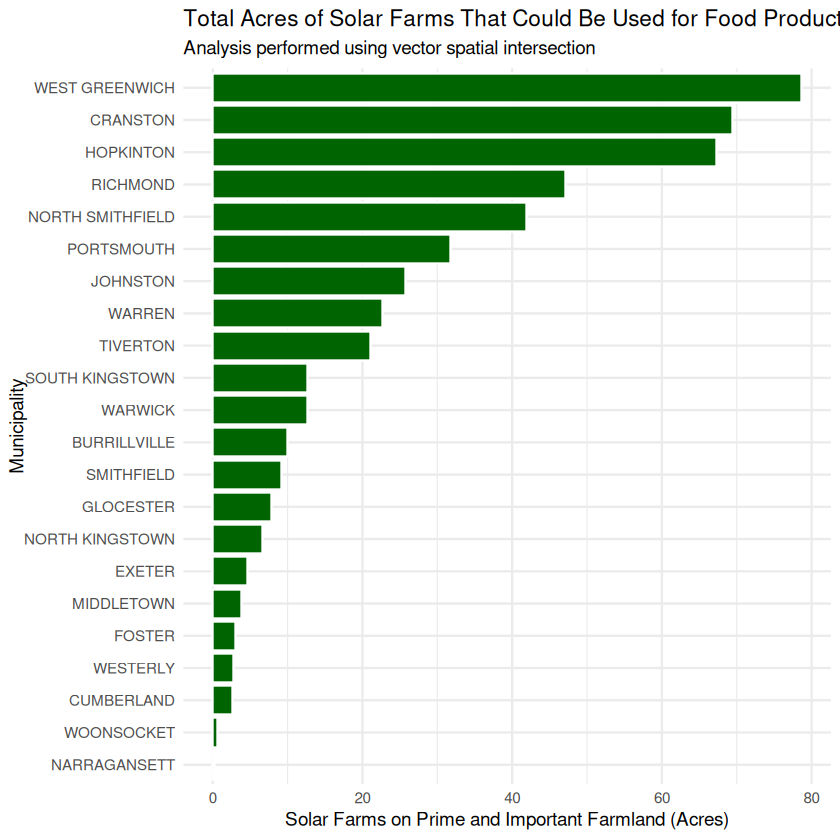

In [33]:
# cut the land_use polygons by the municipality boundaries
intersections2 <- st_intersection(solar_farmland_overlap, municipalities)

# calculate the area of the new intersected pieces - farmland between town lines
intersections2$area_sqm <- st_area(intersections2)

# Create a summary plot
solar_summary <- intersections2 %>%
  st_drop_geometry() %>% # Convert to a standard table for faster math
  group_by(NAME) %>%
  summarize(total_overlap_acres = sum(overlap_acres, na.rm = TRUE)) %>%
  arrange(desc(total_overlap_acres))

# create a bar chart of total acres of solar farms on prime and important farmland by municipality
ggplot(solar_summary, aes(x = reorder(NAME, total_overlap_acres), y = total_overlap_acres)) +
  geom_col(fill = "darkgreen", color = "white") +
     coord_flip() +  # Flip the chart to make municipality names readable
  labs(
    title = "Total Acres of Solar Farms That Could Be Used for Food Production by Municipality",
    subtitle = "Analysis performed using vector spatial intersection",
    x = "Municipality",
    y = "Solar Farms on Prime and Important Farmland (Acres)"
  ) +
  theme_minimal()

Which polygons in the solar dataset overlap with the polygons in the farmland dataset?


In [5]:
library(HelpersMG)

tenft_contour_ri <- wget("https://drive.google.com/drive/u/0/folders/1oZSVDDUmpdgAZR1guTiMYa63oq9ySdtJ")
head(tenft_contour_ri)

NULL

Practice


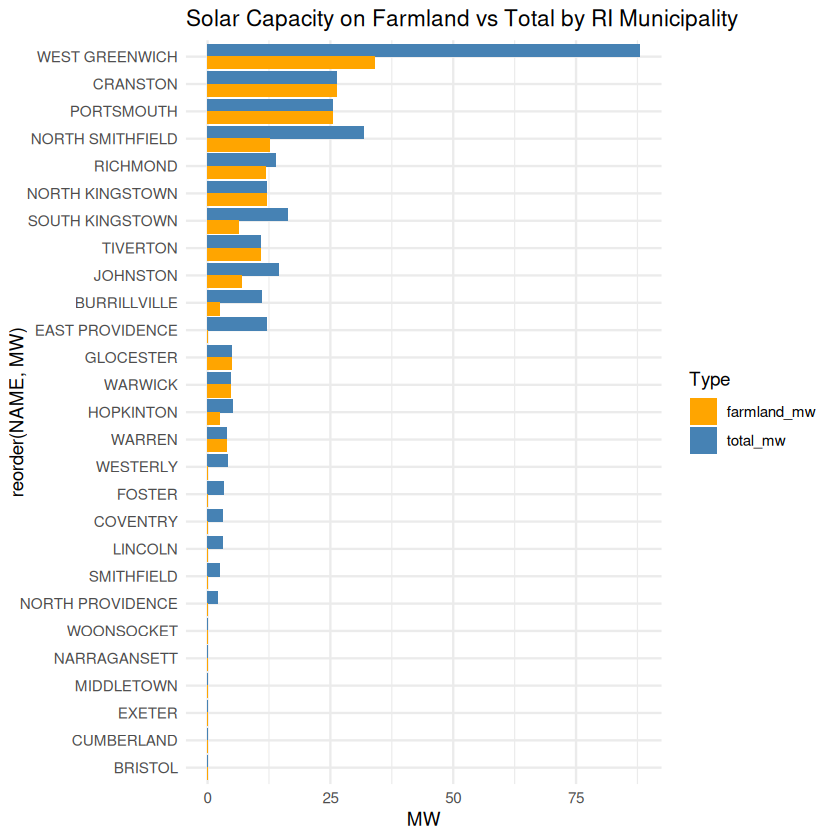

In [18]:
plot_data <- ri_solar_farmland_class %>%
  select(NAME, total_mw, farmland_mw) %>%
  pivot_longer(cols = c(total_mw, farmland_mw), names_to = "Type", values_to = "MW")

ggplot(plot_data, aes(x = reorder(NAME, MW), y = MW, fill = Type)) +
  geom_col(position = "dodge") +
  coord_flip() +
  scale_fill_manual(values = c("total_mw" = "steelblue", "farmland_mw" = "orange")) +
  labs(title = "Solar Capacity on Farmland vs Total by RI Municipality") +
  theme_minimal()